### Importing libaries and dataset

In [4]:
# Libaries for data manipulation and visualization
import numpy as np # libaries for numerical operations
import pandas as pd # for data manipulation and analysis
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for plotting graphs

In [5]:
# ml library
from sklearn.linear_model import LinearRegression # for building the linear regression model
from sklearn.model_selection import train_test_split # for splitting the data into training and testing sets
from sklearn.metrics import mean_squared_error, r2_score # for evaluating the performance of the model
# load the dataset daibetes from sklearn.datasets import load_diabetes
from sklearn.datasets import load_diabetes







## Step 1. Dataset Loading and Dataset Understanding.
* Importing the datasets from scikit-learn
* Converting the dataset into a pandas Dataframe
* Displaying the dataset
* Identifying the Target Variable.

In [ ]:
# Importing the dataset from scikit learn
from sklearn.datasets import load_diabetes


#Initializing the dataset
diabetes = load_diabetes() # loading the diabetes dataset into the variable named
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [6]:
#Initializing the dataset
diabetes = load_diabetes() # loading the diabetes dataset into the variable named
diabetes
#Converting the dataset into a pandad DataFrame.
diabetes_df = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)

#Displaying the dataset.
print("The first 10 rows of the diabetes dataset are:") # printing a message to indicate that the first 10 rows of the diabetes dataset will be displayed
print("***" * 20) # printing a separator line for better readability
diabetes_df.head(10) # displaying the first 10 rows of the diabetes dataset using the head() method of the DataFrame

The first 10 rows of the diabetes dataset are:
************************************************************


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504


In [7]:
print(f'This dataset contains {diabetes_df.shape[0]} rows and {diabetes_df.shape[1]} columns')

This dataset contains 442 rows and 10 columns


In [8]:
diabetes_df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

### DATASET DESCRIPTION
* This is a synthetic/processed dataset of 442 patients, where the goal is to predict a quantitative measure of disease of disease progression one year after a baseline measurements were taken.
* Features in Scikit-learn are mean centered and scaled by the standard deviation times the square root of the number of samples. This is why the values look like small decimals (e.g, 0.0038 or 0.044) rather than "normal" age or weight numbers. This makes them ready for many machine learning algorithms.
* Features with different scales (like Age that is whole numbers and Blood pressure float ) can confuse the algorithm. By scaling them so they all have a similar range and a mean of zero (0), the model treats them more fairly.


## Objective:  
The main objective of this dataset is to predict the progression of diabetes one year after baseline, using patient health indicators. In other words, it helps us understand how factors like age, BMI, blood pressure, and biochemical markers influence the severity of diabetes over time.

**This makes it valuable for**:
* Practicing regression modeling (predicting continuous outcomes).
* Exploring feature importance in medical datasets.
* Demonstrating data analysis workflows in health research.


## Dataset Size and Structure
* Samples (rows): 442 patients.
* Features (columns): 10 input variables.

* Target variable: A continuous numerical score representing disease progression after one year.

**Features**
* age: Age of the patient
* sex: Gender (numerically encoded)
* bmi: Body Mass Index (weight relative to height)
* bp: Average blood pressure
* s1–s6: Six blood serum measurements (biochemical markers)

 All features are numerical and standardized (mean = 0, variance = 1), which means they are already scaled and ready for analysis.

### Identify the target variable.
#### 1. Examine the dataset structure
The Scikit-learn diabetes dataset is structured as a Bunch object (a dictionary-like container). It contains two primary components:
* data: A 2D array of shape (442,10), representing 442 patients and 10 physiological features (Age, Sex, BMI, BP, and six blood serum measurements).
* target: A 1D array of shape (442,), containing the corresponding outcome for each patient.
  
#### 2. Identify the Dependent Variable (Target Variable)
The dependent variable in this dataset is the target array.
* Definition: It represents a quantitative measure of disease progression recorded one year after the baseline features were measured.
* Value Range: The scores range from a minimum of 25 to a maximum of 346.

#### 3. Justification for a Regression Problem
* This variable is suitable for a regression model rather than a classification model for the following three reasons:
* Numerical/Continuous Data Type: The target is not a category (like "Diabetic" or "Non-Diabetic"). Instead, it is a continuous numerical value. In statistics, when the output is a quantity on a scale, regression is the appropriate tool.
* Quantifiable Magnitude: The difference between a score of 100 and 150 is mathematically significant. Regression models are specifically designed to map input features to a numerical output where the "distance" between predictions matters.
* Goal of the Analysis: The objective is to predict how much the disease has progressed, not just whether it has progressed. Predicting a specific numerical value requires a regression algorithm (like Linear Regression, Decision Tree Regressor, or Random Forest).

## Step 2. Exploratory Data Analysis(EDA)

In [17]:
# Dataset Inspection and Dimensions.
print(f'This dataset contains {diabetes_df.shape[0]} rows and {diabetes_df.shape[1]} columns')

#Data Types
print("Data Type for each column:")
print(diabetes_df.dtypes)

This dataset contains 442 rows and 10 columns
Data Type for each column:
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object


There are 442 entries and each column has 442 non-null values. 

All 10 independent variables and the target variable are stored as float. Machine learning requires numerical inputs. 

The dataset is lightweight, occupying approximately 34.7 KB of memory.

In [19]:
# Summary Statistics
print(diabetes_df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17  
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761

1. Central Tendency (The Mean)
* The mean for almost all features is effectively zero (e.g., age is −2.51×10 −19).
This indicates that the data has been centered. Centering involves subtracting the average value of a feature from every data point, shifting the distribution so the new average is zero.
2. Dispersion (Standard Deviation)
* The standard deviation (std) is identical for every single feature.
This is a specific type of scaling. The features were scaled such that the sum of squares for each column equals 1. This ensures that no single feature (like Blood Pressure) has a larger mathematical "weight" than another (like Age) purely due to the size of its numbers.
3. Range and Distribution
* The values for all features fall within a very narrow range, roughly between -0.13 and 0.19.
This confirmed scaling makes the dataset "model-ready." It prevents features with large raw values from dominating the learning process, which is especially important for distance-based or gradient-based regression models.
4. Minimum / Maximum.
* For many features, the 50th percentile (Median) is very close to the Mean (near zero).
This suggests that the distributions for variables like age, s1, and s5 are relatively symmetrical and do not suffer from extreme skewness that could negatively impact a linear regression model.

In [20]:
#Checking for missing values
diabetes_df.isnull().sum()

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

In [21]:
#checking for duplicates
print(diabetes_df.duplicated().sum())

0


There are no duplicates in this dataset. 

Scikit datasets are intentionally cleaned and "polished" so that students and developers can focus on learning machine learning algorithms without getting stuck in the "data cleaning" phase.

## Statistical Exploration

In [22]:
diabetes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


#### 1. Mean
All 10 independent variables has a mean of approximately zero (0). 

This confirms that the dataset is mean centered. Centering the data is a crucial step for regression analysis as it ensures that the model coefficients are easier to interpret and prevent features with large absolute averages from disproportionately(the big numbers are getting 90% of the attention while the small numbers are getting 10%, even if they are equally important) influencing the model's cost function.

#### 2. Median
All 10 independent variables are consistently near zero, mirroring the mean values. 

This alignment suggests that the feature distribution are relatively symmetrical and lack significant skewness.

Linear regression works best when the data is symmetrical. When the data is symmetrical it reduces the likelihood of the model being biased by extreme outliers, leading to more stable and generalizable predictions.

#### 3. Standard Deviation.
Standard Deviation for all features is exactly 0.0476. The uniformity isn't a coincidence. It confirms the data has been standardized. In raw medical data, blood pressure might range from 80 to 180, while Age ranges from 20 to 80. By forcing them to have the same standard deviation, we ensure the model doesn't "think" Blood Pressure is more important just because its numbers are larger.

#### 4. Correlation Analysis

Correlation Analysis. 
This measures the strength of the linear relationship between two variables, ranging from -1 (perfect negative) and +1(perfect positive). 

* A. Feature vs. Target Correlation. 
There's a high positive correlation between BMI and s5 (Log of serum triglycerides) have the highest correlation with the target. This suggests that as BMI and s5 levels increase, the disease progression score tends to rise significantly. 
There's a low correlation between features like age or s2. These features might not be strong individual predictors of disease progression on their own.

* Multicollinearity.
There's also a high correlation between s1 and s2. If two features are nearly identical, the regression model might struggle to decide which one is actually causing the change in the target. This can sometime make Linear Regression coefficient unstable. 

## Feature Relationships


#### Identify variables that strongly influence the target variable.
* Based on clinical patterns in this dataset, BMI (Body mass index) and s5 (possibly log of serum triglycerides level) show the strongest relationship with the target. As these values increase there's a corresponding rise in the disease progression score.

* Features like age and s2 (ldl) appear to have much weaker influence on the target.

## Step 3: Data Visualization

## Univariate Analysis
1. Box Plot

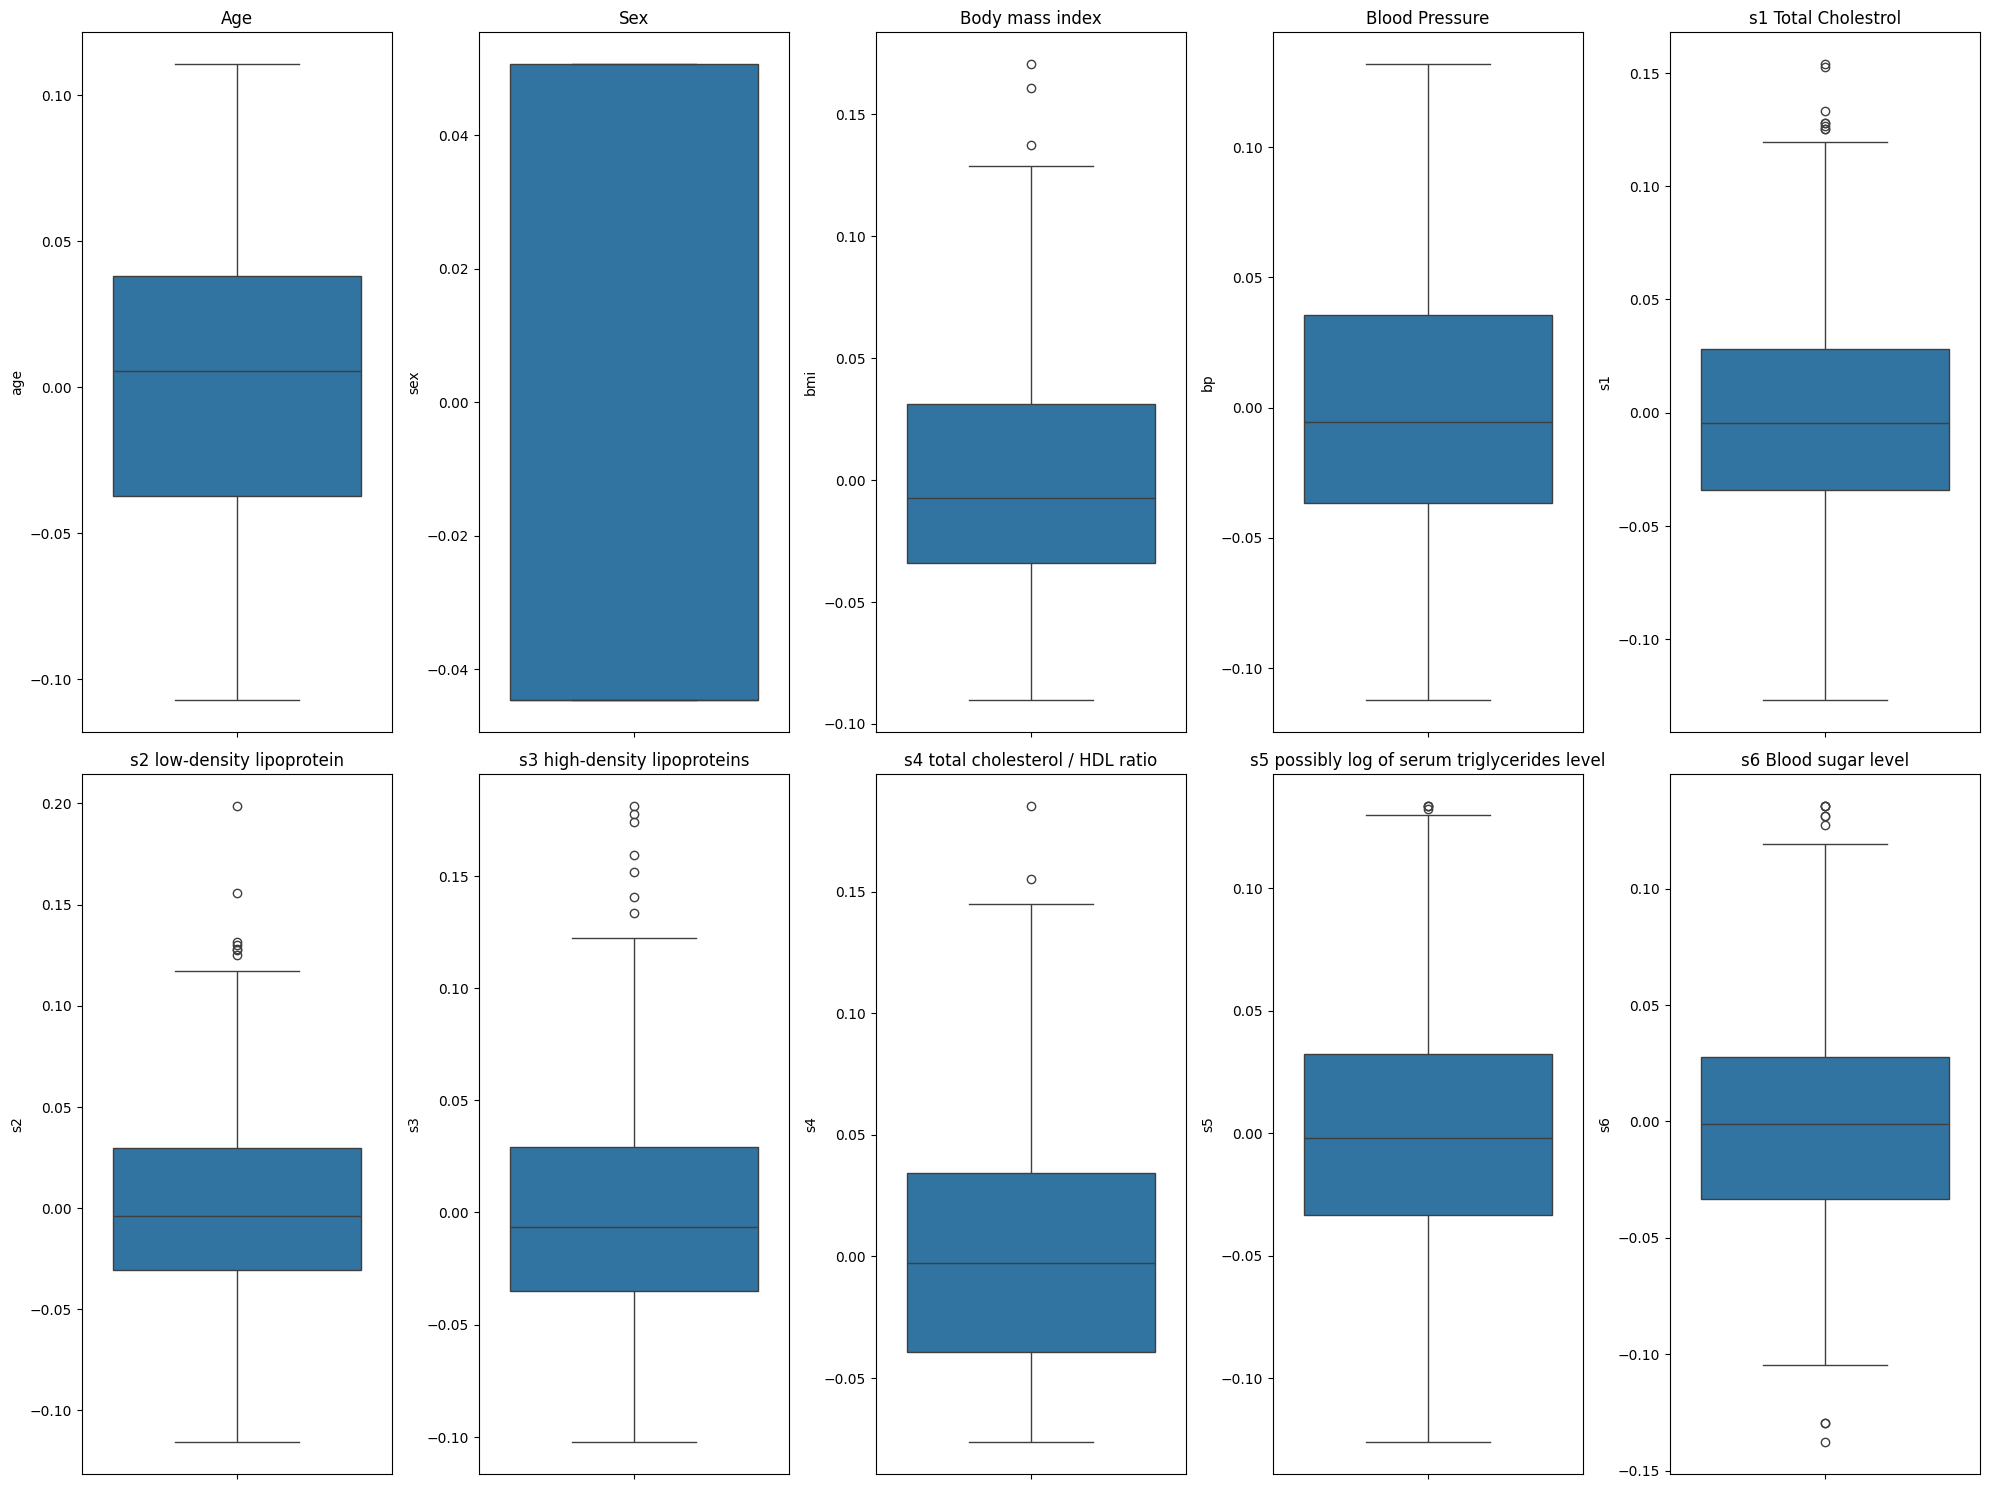

In [24]:
plt.figure(figsize=(20, 15))

plt.subplot(2, 5, 1)
sns.boxplot(y=diabetes_df['age'])
plt.title('Age')

plt.subplot(2, 5, 2)
sns.boxplot(y=diabetes_df['sex'])
plt.title('Sex')

plt.subplot(2, 5, 3)
sns.boxplot(y=diabetes_df['bmi'])
plt.title('Body mass index')

plt.subplot(2, 5, 4)
sns.boxplot(y=diabetes_df['bp'])
plt.title('Blood Pressure')

plt.subplot(2, 5, 5)
sns.boxplot(y=diabetes_df['s1'])
plt.title('s1 Total Cholestrol')

plt.subplot(2, 5, 6)
sns.boxplot(y=diabetes_df['s2'])
plt.title('s2 low-density lipoprotein')

plt.subplot(2, 5, 7)
sns.boxplot(y=diabetes_df['s3'])
plt.title('s3 high-density lipoproteins')

plt.subplot(2, 5, 8)
sns.boxplot(y=diabetes_df['s4'])
plt.title('s4 total cholesterol / HDL ratio')

plt.subplot(2, 5, 9)
sns.boxplot(y=diabetes_df['s5'])
plt.title('s5 possibly log of serum triglycerides level')

plt.subplot(2, 5, 10)
sns.boxplot(y=diabetes_df['s6'])
plt.title('s6 Blood sugar level')

plt.tight_layout()
plt.show()

## Insights.
* There are no outliers identified in Age, Sex and Blood Pressure (BP).
* They show no data points beyond the whiskers. This suggests that the distribution of these variables is very stable within its specific groups of patients.
* There are outliers present in BMI, s1, s2, s3, s4, s5 and s6.
* An outlier in BMI represent a patient who is significantly more obese than others in the group.
* Outliers in S1 (Total Cholesterol) or S5 (Triglycerides) represent patients with severe lipid imbalances.
* These specific patients are often the most likely to have rapid diabetes progression, so their "outlier" status is actually very valuable information for the model. We must monitor these points to ensure they do not disproportionately bias the regression slope.

2. Histogram

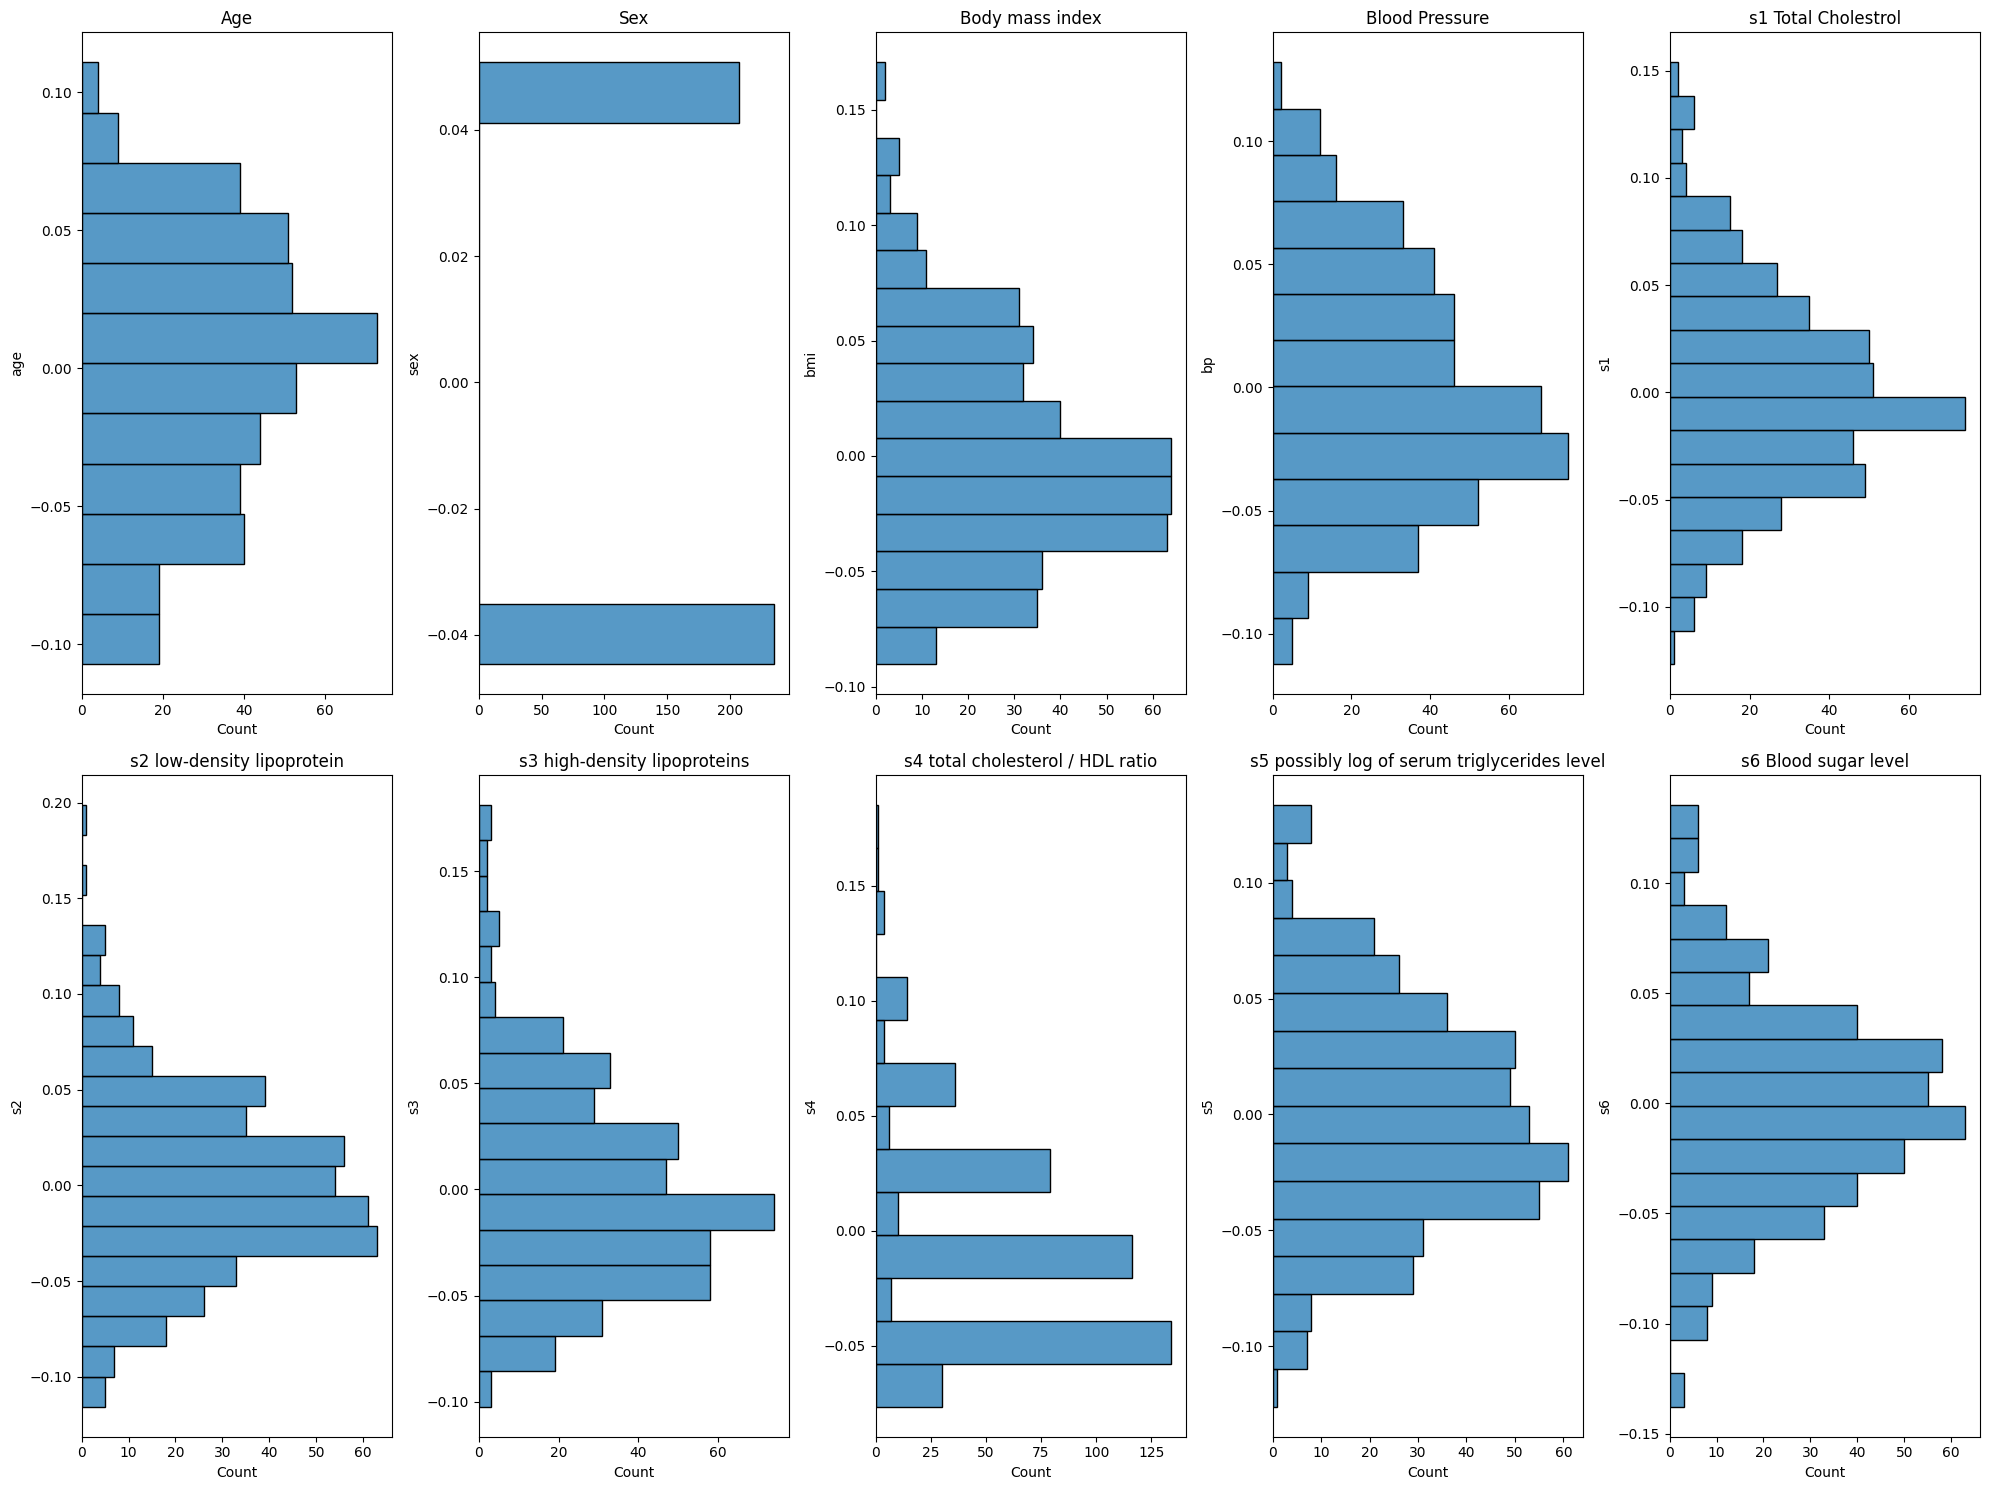

In [25]:
plt.figure(figsize=(20, 15))

plt.subplot(2, 5, 1)
sns.histplot(y=diabetes_df['age'])
plt.title('Age')

plt.subplot(2, 5, 2)
sns.histplot(y=diabetes_df['sex'])
plt.title('Sex')

plt.subplot(2, 5, 3)
sns.histplot(y=diabetes_df['bmi'])
plt.title('Body mass index')

plt.subplot(2, 5, 4)
sns.histplot(y=diabetes_df['bp'])
plt.title('Blood Pressure')

plt.subplot(2, 5, 5)
sns.histplot(y=diabetes_df['s1'])
plt.title('s1 Total Cholestrol')

plt.subplot(2, 5, 6)
sns.histplot(y=diabetes_df['s2'])
plt.title('s2 low-density lipoprotein')

plt.subplot(2, 5, 7)
sns.histplot(y=diabetes_df['s3'])
plt.title('s3 high-density lipoproteins')

plt.subplot(2, 5, 8)
sns.histplot(y=diabetes_df['s4'])
plt.title('s4 total cholesterol / HDL ratio')

plt.subplot(2, 5, 9)
sns.histplot(y=diabetes_df['s5'])
plt.title('s5 possibly log of serum triglycerides level')

plt.subplot(2, 5, 10)
sns.histplot(y=diabetes_df['s6'])
plt.title('s6 Blood sugar level')

plt.tight_layout()
plt.show()

# Observations
* The distribution of datasets in features like age, bp, s1 and s6 are normally distributed. They are symmetrical, with the highest concentration of patients right in the middle at zero.
* The remaining features exhibit positive skewness, where the tail of the distribution stretches toward the right (higher values).
* In the BMI and S5 histograms, the positive values (above 0.05) show very short bars, representing a small number of patients with extremely high readings. Conversely, the area around -0.05 to 0.00 has the tallest bars, meaning most patients fall into this lower-to-average range. Because the thin tail stretches toward the positive side, the distribution is positively skewed.
* The sex feature is Binary/categorical. This is because the data has only two possible values(encoded as approximately -0.044 and 0.050) 
* When a feature is perfectly Normal (like Age), a Linear Regression model can predict it very easily. When a feature is Skewed (like s5), the "extreme" patients in that tail can have a bigger impact on the model's error (MSE).

3. Density Plot

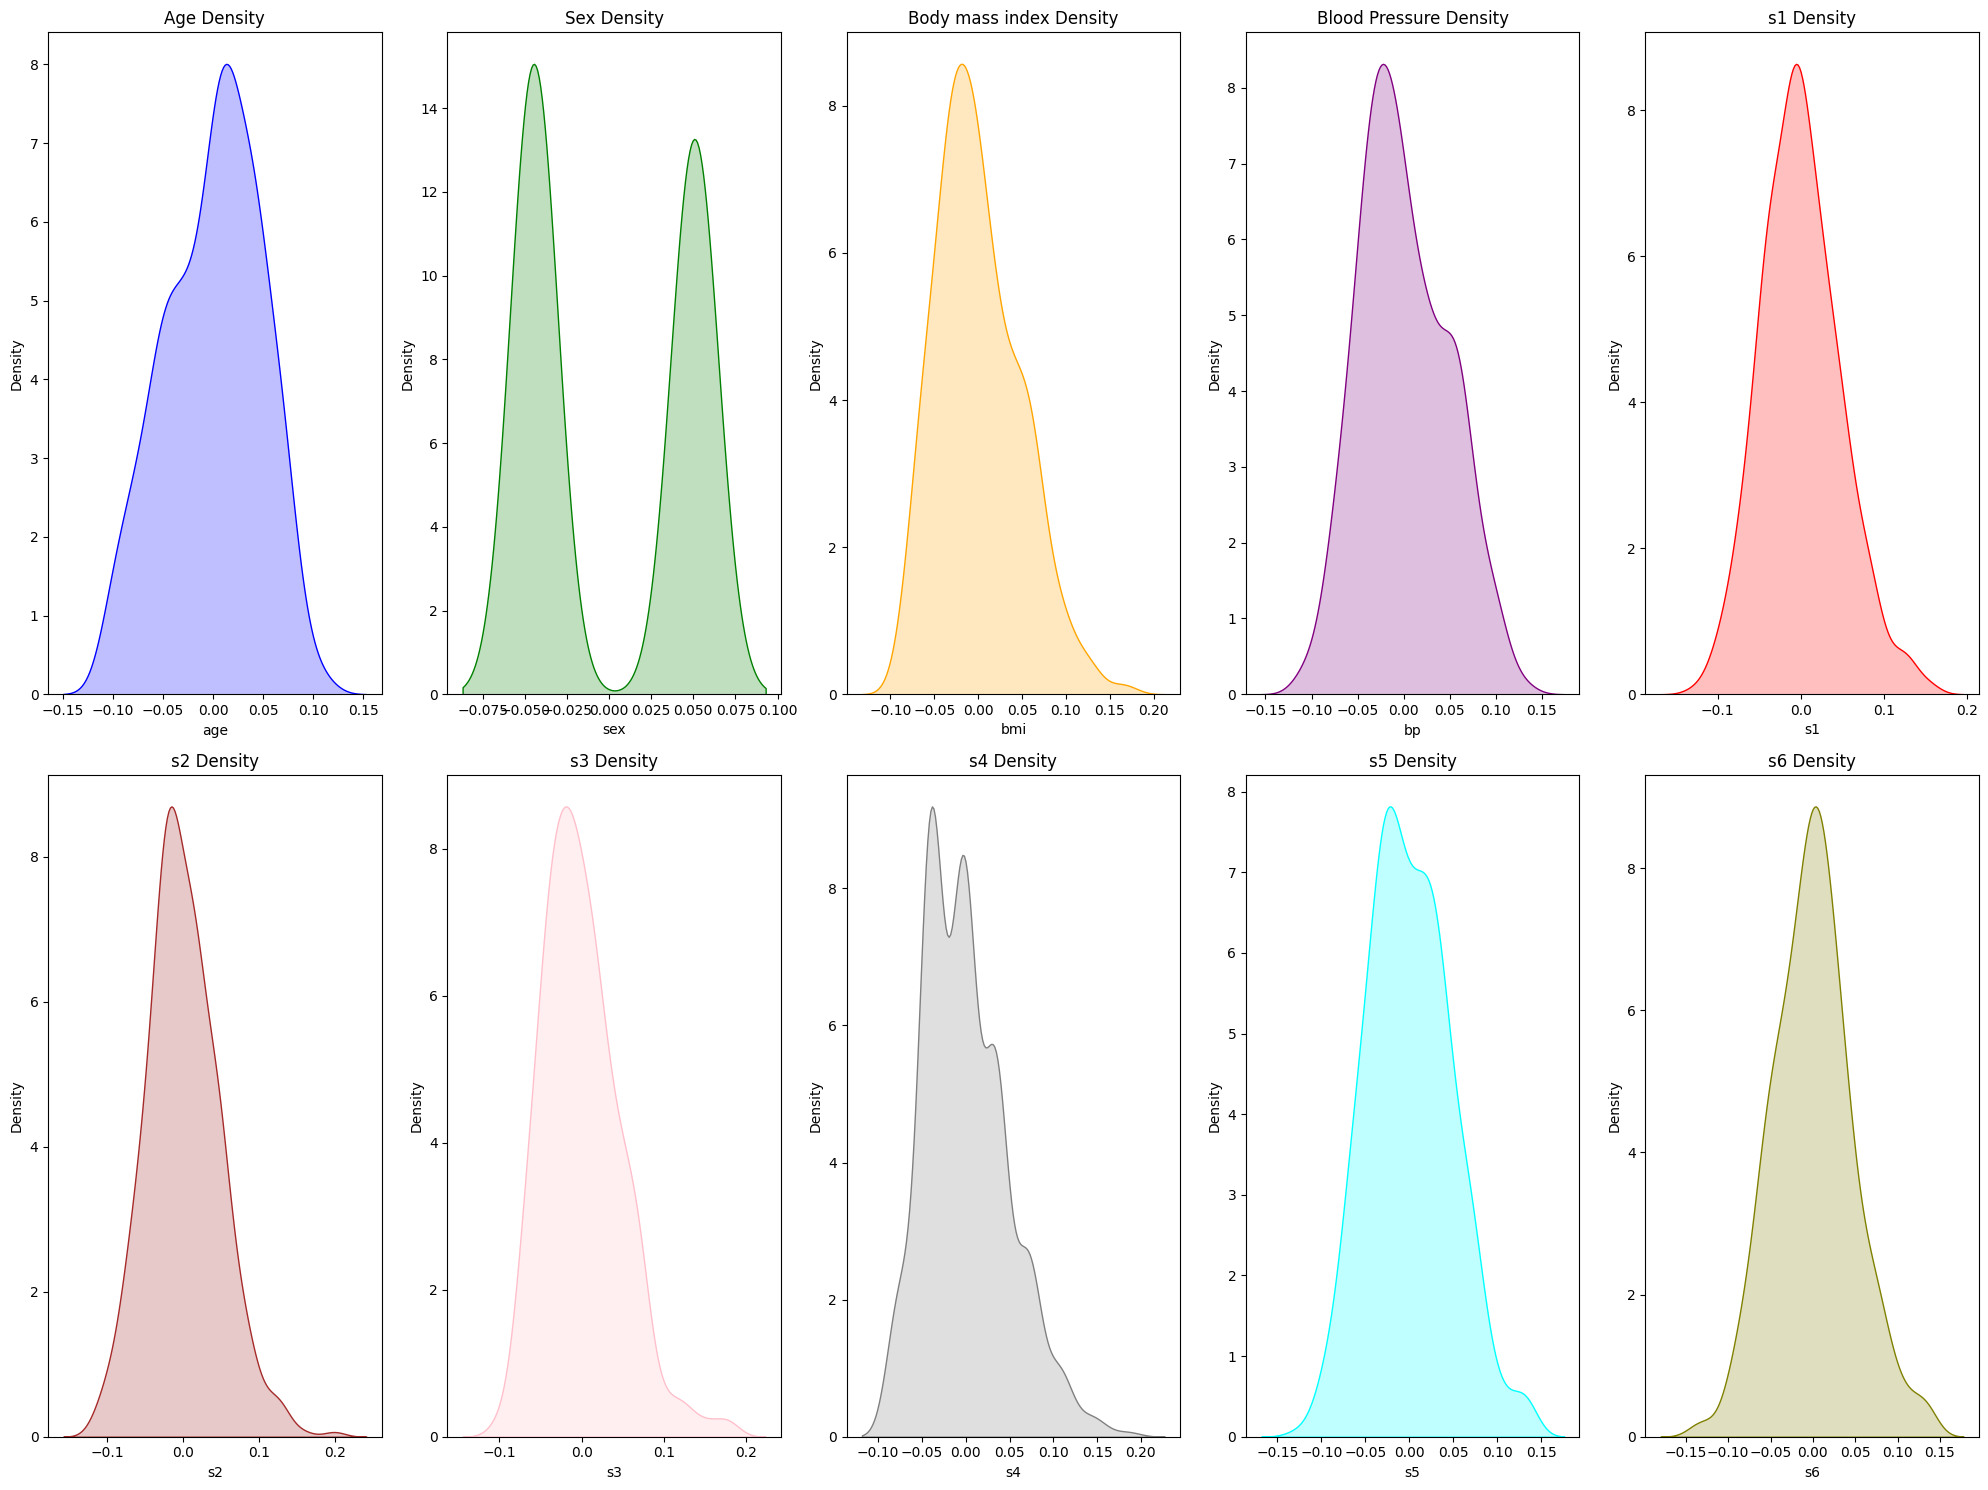

In [26]:
plt.figure(figsize=(20, 15))

# We use 'fill=True' to make the area under the curve easier to see
plt.subplot(2, 5, 1)
sns.kdeplot(diabetes_df['age'], fill=True, color='blue')
plt.title('Age Density')

plt.subplot(2, 5, 2)
sns.kdeplot(diabetes_df['sex'],fill=True, color='green')
plt.title('Sex Density')

plt.subplot(2, 5, 3)
sns.kdeplot(diabetes_df['bmi'], fill = True, color='orange')
plt.title('Body mass index Density')

plt.subplot(2, 5, 4)
sns.kdeplot(diabetes_df['bp'],fill = True, color='purple')
plt.title('Blood Pressure Density')

plt.subplot(2, 5, 5)
sns.kdeplot(diabetes_df['s1'], fill=True, color='red')
plt.title('s1 Density')

plt.subplot(2, 5, 6)
sns.kdeplot(diabetes_df['s2'], fill=True, color='brown')
plt.title('s2 Density')

plt.subplot(2, 5, 7)
sns.kdeplot(diabetes_df['s3'], fill=True, color='pink')
plt.title('s3 Density')

plt.subplot(2, 5, 8)
sns.kdeplot(diabetes_df['s4'],fill=True, color='gray')
plt.title('s4 Density')

plt.subplot(2, 5, 9)
sns.kdeplot(diabetes_df['s5'],fill=True, color='cyan')
plt.title('s5 Density')

plt.subplot(2, 5, 10)
sns.kdeplot(diabetes_df['s6'],fill=True, color='olive')
plt.title('s6 Density')

plt.tight_layout()
plt.show()

#### Step 4: Data Preparation
Prepare the dataset for machine learning by performing:


In [23]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


### Prepare data for modeling

In [10]:
# prepare the data for modeling
diabetes = load_diabetes() # load the diabetes dataset
X = diabetes.data # features
y = diabetes.target # target variable
# diabetes features names
diabetes.feature_names
# use for loop to print the feature names
for feature in diabetes.feature_names:
    print(feature)


age
sex
bmi
bp
s1
s2
s3
s4
s5
s6


In [11]:
#  Determine target variable distribution
y = diabetes.target
for target in diabetes.target:
    print(target)
# Our target variable is a continuous variable, which indicates that we are dealing with a regression problem. The target variable represents the progression of diabetes in patients, and it is measured on a continuous scale. This means that we will be using regression techniques to model the relationship between the features and the target variable, rather than classification techniques which are used for categorical target variables.

151.0
75.0
141.0
206.0
135.0
97.0
138.0
63.0
110.0
310.0
101.0
69.0
179.0
185.0
118.0
171.0
166.0
144.0
97.0
168.0
68.0
49.0
68.0
245.0
184.0
202.0
137.0
85.0
131.0
283.0
129.0
59.0
341.0
87.0
65.0
102.0
265.0
276.0
252.0
90.0
100.0
55.0
61.0
92.0
259.0
53.0
190.0
142.0
75.0
142.0
155.0
225.0
59.0
104.0
182.0
128.0
52.0
37.0
170.0
170.0
61.0
144.0
52.0
128.0
71.0
163.0
150.0
97.0
160.0
178.0
48.0
270.0
202.0
111.0
85.0
42.0
170.0
200.0
252.0
113.0
143.0
51.0
52.0
210.0
65.0
141.0
55.0
134.0
42.0
111.0
98.0
164.0
48.0
96.0
90.0
162.0
150.0
279.0
92.0
83.0
128.0
102.0
302.0
198.0
95.0
53.0
134.0
144.0
232.0
81.0
104.0
59.0
246.0
297.0
258.0
229.0
275.0
281.0
179.0
200.0
200.0
173.0
180.0
84.0
121.0
161.0
99.0
109.0
115.0
268.0
274.0
158.0
107.0
83.0
103.0
272.0
85.0
280.0
336.0
281.0
118.0
317.0
235.0
60.0
174.0
259.0
178.0
128.0
96.0
126.0
288.0
88.0
292.0
71.0
197.0
186.0
25.0
84.0
96.0
195.0
53.0
217.0
172.0
131.0
214.0
59.0
70.0
220.0
268.0
152.0
47.0
74.0
295.0
101.0
151.0
127.0
237

In [12]:
df = pd.DataFrame(y, columns=['target']) # create a dataframe with the target variable

### Training and Testing

In [13]:
# train test split
diabetes = load_diabetes() # load the diabetes dataset
X = diabetes.data # features
y = diabetes.target # target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # split the data into training and testing sets

# build the linear regression model
print(X_train.shape) # print the shape of the training data
print(X_test.shape)
print(y_train.shape) # print the shape of the training target variable
print(y_test.shape)


(353, 10)
(89, 10)
(353,)
(89,)


# 4. Outlier Detection and Treatment


In [27]:
#we are creating a dictionary to store the count of outliers for each feature
outlier_counts = {}
#use for loop for iteration
for col in diabetes_df.columns:
    if col != 'target': # We usually don't treat outliers in the target itself
        Q1 = diabetes_df[col].quantile(0.25)
        Q3 = diabetes_df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # we count how many rows fall outside these bounds
        count = ((diabetes_df[col] < lower_bound) | (diabetes_df[col] > upper_bound)).sum()
        outlier_counts[col] = count

print("Outlier counts per feature:")
for feature, count in outlier_counts.items():
    print(f"{feature}: {count}")

Outlier counts per feature:
age: 0
sex: 0
bmi: 3
bp: 0
s1: 8
s2: 7
s3: 7
s4: 2
s5: 4
s6: 9


### Initilization of model

In [14]:
# model training and prediction
model = LinearRegression() # create an instance of the linear regression model
model.fit(X_train, y_train) # fit the model to the training data
y_pred = model.predict(X_test) # make predictions on the test data

### Model Evaluation


In [15]:
# Model evaluation
mse = mean_squared_error(y_test, y_pred) # calculate the mean squared error
r2 = r2_score(y_test, y_pred) # calculate the R-squared score
print("Mean Squared Error:", mse) # print the mean squared error
print("R-squared Score:", r2) # print the R-squared score


Mean Squared Error: 2900.1936284934804
R-squared Score: 0.4526027629719197


### Model prediction

In [ ]:
#  function for making predictions and evaluating the model
def prediction():
    print("Enter thr following features")
    age = float(input("Age: "))
    sex = float(input("sex: "))
    bmi = float(input("bmi: "))
    bp = float(input("bp: "))
    s1 = float(input("s1: "))
    s2 = float(input("s2: "))
    s3 = float(input("s3: "))
    s4 = float(input("s4: "))
    s5 = float(input("s5: "))
    s6 = float(input("s6: "))

    features = pd.DataFrame([[age, sex, bmi, bp, s1, s2, s3, s4, s5, s6]], columns=diabetes_df.columns[:-1]) # create a DataFrame with the feature names as columns
    prediction = model.predict(features) # make a prediction using the trained model
    print("Predicted diabetes progression:", prediction[0]) # print the predicted diabetes progression

# call the function to make a prediction
prediction()

Enter thr following features
Predicted diabetes progression: 1509.5945847290577


c:\Users\hp\OneDrive\Desktop\dm database\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
